## Importing All Necessary Libraries

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

## Importing Datasets

In [54]:
dataset_1 = pd.read_csv("emotion_dataset_raw.csv")
dataset_2 = pd.read_csv("combined_emotion.csv")

In [55]:
print(dataset_1.shape)
print(dataset_2.shape)

(34792, 2)
(422746, 2)


In [56]:
print("Dataset 1: ", dataset_1)
print("Dataset 2: ", dataset_2)

Dataset 1:          Emotion                                               Text
0       neutral                                             Why ? 
1           joy    Sage Act upgrade on my to do list for tommorow.
2       sadness  ON THE WAY TO MY HOMEGIRL BABY FUNERAL!!! MAN ...
3           joy   Such an eye ! The true hazel eye-and so brill...
4           joy  @Iluvmiasantos ugh babe.. hugggzzz for u .!  b...
...         ...                                                ...
34787  surprise  @MichelGW have you gift! Hope you like it! It'...
34788       joy  The world didnt give it to me..so the world MO...
34789     anger                           A man robbed me today . 
34790      fear  Youu call it JEALOUSY, I call it of #Losing YO...
34791   sadness  I think about you baby, and I dream about you ...

[34792 rows x 2 columns]
Dataset 2:                                                   sentence emotion
0           i just feel really helpless and heavy hearted    fear
1       ive en

In [57]:
print(len(dataset_1))
print(len(dataset_2))

34792
422746


In [58]:
print(dataset_1.head(5000).to_string())

       Emotion                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            Text
0      neutral                                                                                                                                                                                                                                                                                                                                                                                                                                                           

## Imporitng Libraries to preprocess data

In [59]:
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\moham\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\moham\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

## Dataset_1

In [60]:
copy_d1 = dataset_1.copy()

In [61]:
print(copy_d1)

        Emotion                                               Text
0       neutral                                             Why ? 
1           joy    Sage Act upgrade on my to do list for tommorow.
2       sadness  ON THE WAY TO MY HOMEGIRL BABY FUNERAL!!! MAN ...
3           joy   Such an eye ! The true hazel eye-and so brill...
4           joy  @Iluvmiasantos ugh babe.. hugggzzz for u .!  b...
...         ...                                                ...
34787  surprise  @MichelGW have you gift! Hope you like it! It'...
34788       joy  The world didnt give it to me..so the world MO...
34789     anger                           A man robbed me today . 
34790      fear  Youu call it JEALOUSY, I call it of #Losing YO...
34791   sadness  I think about you baby, and I dream about you ...

[34792 rows x 2 columns]


In [62]:
duplicates = copy_d1['Text'].duplicated()
print(duplicates)

0        False
1        False
2        False
3        False
4        False
         ...  
34787    False
34788    False
34789    False
34790    False
34791    False
Name: Text, Length: 34792, dtype: bool


In [63]:
duplicates = copy_d1['Text'].duplicated().sum()
print(duplicates)

3682


In [64]:
copy_d1 = copy_d1.drop_duplicates(subset=['Text'])
print(copy_d1)

        Emotion                                               Text
0       neutral                                             Why ? 
1           joy    Sage Act upgrade on my to do list for tommorow.
2       sadness  ON THE WAY TO MY HOMEGIRL BABY FUNERAL!!! MAN ...
3           joy   Such an eye ! The true hazel eye-and so brill...
4           joy  @Iluvmiasantos ugh babe.. hugggzzz for u .!  b...
...         ...                                                ...
34787  surprise  @MichelGW have you gift! Hope you like it! It'...
34788       joy  The world didnt give it to me..so the world MO...
34789     anger                           A man robbed me today . 
34790      fear  Youu call it JEALOUSY, I call it of #Losing YO...
34791   sadness  I think about you baby, and I dream about you ...

[31110 rows x 2 columns]


In [65]:
has_nan = copy_d1[['Text', 'Emotion']].isna().any()
print(has_nan)

Text       False
Emotion    False
dtype: bool


In [66]:

mask = copy_d1['Text'].str.contains(r'href|http|https|www|html|amp|nbsp', case=False, regex=True, na=False).sum()
print(mask)
mask = copy_d1['Text'].str.contains(r'@\w+',  case=False, regex=True, na=False).sum()  
print(mask)
mask = copy_d1['Text'].str.contains(r'#\w+',  case=False, regex=True, na=False).sum()
print(mask)
mask = copy_d1['Text'].str.contains(r'&\w+;',  case=False, regex=True, na=False).sum()
print(mask)
mask = ~copy_d1['Text'].str.isascii()
print(mask.sum())

1454
5068
4267
2119
1421


In [67]:
# Initialize
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
HTML_TAGS = re.compile(r'\b(href|http|https|www|html|amp|nbsp)\w*\b')

def preprocess_1(text):
    # 1. Lowercase
    text = text.lower()
    #remove hashtags
    text = re.sub(r'#\w+', '', text)
    
    #remove usernmae
    text = re.sub(r'@\w+', '', text)
    
    #remove &words
    text = re.sub(r'&\w+', '', text)
    
    #remove htmls tags              
    text = HTML_TAGS.sub(' ', text)   
    
     # 5. Remove emojis / non-ASCII characters
    text = text.encode('ascii', 'ignore').decode('ascii')
    
    # 2. Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # 3. Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # 4. Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    # 5. Tokenization
    tokens = word_tokenize(text)
    
    # 6. Remove stopwords
    tokens = [t for t in tokens if t not in stop_words]
    
    # 7. Stemming
    tokens = [stemmer.stem(t) for t in tokens]
    
    # 8. Join back
    return ' '.join(tokens)

In [68]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\moham\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [69]:
copy_d1['Text'] = copy_d1['Text'].apply(preprocess_1)
print("done")

done


In [70]:
mask = copy_d1['Text'].str.contains(r'href|http|https|www|html|amp|nbsp', case=False, regex=True, na=False).sum()
print(mask)
mask = copy_d1['Text'].str.contains(r'@\w+',  case=False, regex=True, na=False).sum()  
print(mask)
mask = copy_d1['Text'].str.contains(r'#\w+',  case=False, regex=True, na=False).sum()
print(mask)
mask = copy_d1['Text'].str.contains(r'&\w+;',  case=False, regex=True, na=False).sum()
print(mask)
mask = ~copy_d1['Text'].str.isascii()
print(mask.sum())

316
0
0
0
0


In [71]:
print(copy_d1['Text'].isnull().sum())

print((copy_d1['Text'] == '').sum())

# view them
print(copy_d1[copy_d1['Text'] == ''])

# --- Remove empty strings ---
copy_d1 = copy_d1[copy_d1['Text'] != '']
copy_d1 = copy_d1.reset_index(drop=True)

0
149
       Emotion Text
0      neutral     
76     neutral     
114    neutral     
269    neutral     
392    neutral     
...        ...  ...
34000  neutral     
34234  neutral     
34243  neutral     
34429  neutral     
34662  neutral     

[149 rows x 2 columns]


In [72]:
print((copy_d1['Text'] == '').sum())

0


In [73]:
mask = copy_d1['Text'].str.contains(r'href|http|https|www|html|amp|nbsp', case=False, regex=True, na=False).sum()
print(mask)

316


In [74]:
print("Original Dataset: " ,dataset_1.head(10))
print("Processed Dataset: " ,copy_d1.head(10))

Original Dataset:      Emotion                                               Text
0   neutral                                             Why ? 
1       joy    Sage Act upgrade on my to do list for tommorow.
2   sadness  ON THE WAY TO MY HOMEGIRL BABY FUNERAL!!! MAN ...
3       joy   Such an eye ! The true hazel eye-and so brill...
4       joy  @Iluvmiasantos ugh babe.. hugggzzz for u .!  b...
5      fear  I'm expecting an extremely important phonecall...
6   sadness   .Couldnt wait to see them live. If missing th...
7  surprise  maken Tip 2: Stop op een moment dat je het hel...
8  surprise  En dan krijg je ff een cadeautje van een tweep...
9  surprise   @1116am Drummer Boy bij op verzoek van @BiemO...
Processed Dataset:      Emotion                                               Text
0       joy                      sage act upgrad list tommorow
1   sadness  way homegirl babi funer man hate funer realli ...
2       joy  eye true hazel eyeand brilliant regular featur...
3       joy  ugh

In [75]:
print(copy_d1.shape)

(30961, 2)


In [76]:
duplicates = copy_d1['Text'].duplicated().sum()
print(duplicates)

678


In [77]:
copy_d1 = copy_d1.drop_duplicates(subset=['Text'])

In [78]:
duplicates = copy_d1['Text'].duplicated().sum()
print(duplicates)

0


In [79]:
# Check if text contains any contraction fragments
contraction_pattern = r"'t|'s|'m|'d|'re|'ve|'ll"
mask_contractions = copy_d1['Text'].str.contains(contraction_pattern, regex=True, na=False)
print(f"Rows with contractions: {mask_contractions.sum()}")

Rows with contractions: 0


In [80]:
print(copy_d1.shape)

(30283, 2)


## Dataset_2

In [81]:
copy_d2 = dataset_2.copy()

In [82]:
print(copy_d2)

                                                 sentence emotion
0           i just feel really helpless and heavy hearted    fear
1       ive enjoyed being able to slouch about relax a...     sad
2       i gave up my internship with the dmrg and am f...    fear
3                              i dont know i feel so lost     sad
4       i am a kindergarten teacher and i am thoroughl...    fear
...                                                   ...     ...
422741                 i begun to feel distressed for you    fear
422742  i left feeling annoyed and angry thinking that...   anger
422743  i were to ever get married i d have everything...     joy
422744  i feel reluctant in applying there because i w...    fear
422745  i just wanted to apologize to you because i fe...   anger

[422746 rows x 2 columns]


In [83]:
duplicates = copy_d2['sentence'].duplicated()
print(duplicates)

0         False
1         False
2         False
3         False
4         False
          ...  
422741     True
422742     True
422743     True
422744     True
422745     True
Name: sentence, Length: 422746, dtype: bool


In [84]:
duplicates = copy_d2['sentence'].duplicated().sum()
print(duplicates)

28924


In [85]:
copy_d2 = copy_d2.drop_duplicates(subset=['sentence'])

In [86]:
has_nan = copy_d2[['sentence', 'emotion']].isna().any()
print(has_nan)

sentence    False
emotion     False
dtype: bool


In [87]:
mask = copy_d2['sentence'].str.contains(r'href|http|https|www|html|amp|nbsp', case=False, regex=True, na=False).sum()
print(mask)
mask = copy_d2['sentence'].str.contains(r'@\w+',  case=False, regex=True, na=False).sum()  
print(mask)
mask = copy_d2['sentence'].str.contains(r'#\w+',  case=False, regex=True, na=False).sum()
print(mask)
mask = copy_d2['sentence'].str.contains(r'&\w+;',  case=False, regex=True, na=False).sum()
print(mask)
mask = ~copy_d2['sentence'].str.isascii()
print(mask.sum())

9244
0
0
0
0


In [88]:
# Check if text contains any contraction fragments
contraction_pattern = r"'t|'s|'m|'d|'re|'ve|'ll"
mask_contractions = copy_d2['sentence'].str.contains(contraction_pattern, regex=True, na=False)
print(f"Rows with contractions: {mask_contractions.sum()}")

Rows with contractions: 0


In [114]:
# Initialize
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
HTML_TAGS = re.compile(r'\b(href|http|https|www|html|amp|nbsp)\w*\b')

def preprocess_2(text):
    # 1. Lowercase 
    text = text.lower()
    
    #remove htmls tags              
    text = HTML_TAGS.sub(' ', text)   
    
    # 2. Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # 3. Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # 4. Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    # 5. Tokenization
    tokens = word_tokenize(text)
    
    # 6. Remove stopwords
    tokens = [t for t in tokens if t not in stop_words]
    
    # 7. Stemming
    tokens = [stemmer.stem(t) for t in tokens]
    
    # 8. Join back
    return ' '.join(tokens)

In [115]:
copy_d2['sentence'] = copy_d2['sentence'].apply(preprocess_2)
print("done")

done


In [116]:
mask = copy_d2['sentence'].str.contains(r'href|http|https|www|html|amp|nbsp', case=False, regex=True, na=False).sum()
print(mask)

727


In [117]:
print(copy_d2['sentence'].isnull().sum())

print((copy_d2['sentence'] == '').sum())


0
9


In [118]:
# --- Remove empty strings ---
copy_d2 = copy_d2[copy_d2['sentence'] != '']
copy_d2 = copy_d2.reset_index(drop=True)

In [119]:
print((copy_d2['sentence'] == '').sum())

0


In [120]:
print("Original Dataset: " ,dataset_2.head(10))
print("Processed Dataset: " ,copy_d2.head(10))

Original Dataset:                                              sentence  emotion
0      i just feel really helpless and heavy hearted     fear
1  ive enjoyed being able to slouch about relax a...      sad
2  i gave up my internship with the dmrg and am f...     fear
3                         i dont know i feel so lost      sad
4  i am a kindergarten teacher and i am thoroughl...     fear
5         i was beginning to feel quite disheartened      sad
6  i would think that whomever would be lucky eno...     love
7  i fear that they won t ever feel that deliciou...      joy
8  im forever taking some time out to have a lie ...  suprise
9  i can still lose the weight without feeling de...      sad
Processed Dataset:                                              sentence  emotion
0                   feel realli helpless heavi heart     fear
1  ive enjoy abl slouch relax unwind frankli need...      sad
2               gave internship dmrg feel distraught     fear
3                              

In [121]:
print(copy_d2.shape)

(393813, 2)


In [122]:
duplicates = copy_d2['sentence'].duplicated().sum()
print(duplicates)

14202


In [123]:
copy_d2 = copy_d2.drop_duplicates(subset=['sentence'])

In [124]:
duplicates = copy_d2['sentence'].duplicated().sum()
print(duplicates)

0


In [127]:
print(copy_d2.shape)

(379611, 2)


## Nahian - Naive Bayes - Multinomial Naive Bayes

## Dataset_1

In [141]:
XN_1 = copy_d1['Text']
YN_1 = copy_d1['Emotion']

In [142]:
from sklearn.model_selection import train_test_split
XN1_train, XN1_test, YN1_train, YN1_test = train_test_split(XN_1, YN_1, test_size=0.2, random_state=42, stratify=YN_1)

## Bag of Words

In [143]:
Bag_o_w = CountVectorizer()
XN_train_bow = Bag_o_w.fit_transform(XN1_train)
XN_test_bow = Bag_o_w.transform(XN1_test)

In [144]:
MNB_BW = MultinomialNB()
MNB_BW.fit(XN_train_bow, YN1_train)

predictions_BW = MNB_BW.predict(XN_test_bow)
print("Accuracy score: ", accuracy_score(YN1_test, predictions_BW))
print("Precision: ", precision_score(YN1_test, predictions_BW, average='weighted'))
print("Recall: ", recall_score(YN1_test, predictions_BW, average='weighted'))
print("F1 Score: ", f1_score(YN1_test, predictions_BW, average='weighted'))

Accuracy score:  0.5563810467228001
Precision:  0.5848819678792966
Recall:  0.5563810467228001
F1 Score:  0.5212632964009482


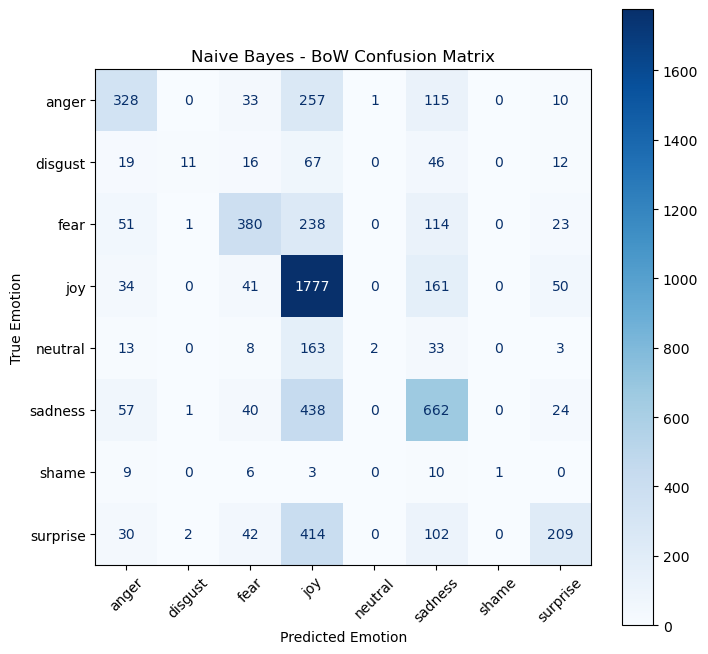

In [152]:
emo_labels = sorted(YN1_test.unique())
NBcm_bow = confusion_matrix(YN1_test, predictions_BW, labels=emo_labels)
NBcm_display_bow = ConfusionMatrixDisplay(confusion_matrix=NBcm_bow, display_labels=emo_labels)

fig, ax = plt.subplots(figsize=(8, 8))
NBcm_display_bow.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Naive Bayes - BoW Confusion Matrix")
plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")
plt.show()

## TF-IDF

In [145]:
TF_IDF_c = TfidfVectorizer()
XN_train_TFIDF = TF_IDF_c.fit_transform(XN1_train)
XN_test_TFIDF = TF_IDF_c.transform(XN1_test)

In [146]:
MNB_TFIDF = MultinomialNB()
MNB_TFIDF.fit(XN_train_TFIDF, YN1_train)

predictions_TFIDF = MNB_TFIDF.predict(XN_test_TFIDF)
print("Accuracy score: ", accuracy_score(YN1_test, predictions_TFIDF))
print("Precision: ", precision_score(YN1_test, predictions_TFIDF, average='weighted'))
print("Recall: ", recall_score(YN1_test, predictions_TFIDF, average='weighted'))
print("F1 Score: ", f1_score(YN1_test, predictions_TFIDF, average='weighted'))

Accuracy score:  0.47036486709592207
Precision:  0.5820018828221848
Recall:  0.47036486709592207
F1 Score:  0.4019746575054667


D:\NLP\NLP Project\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [147]:
from collections import Counter

print("Actual classes:")
print(Counter(YN1_test))

print("\nPredicted classes:")
print(Counter(predictions_TFIDF))

Actual classes:
Counter({'joy': 2063, 'sadness': 1222, 'fear': 807, 'surprise': 799, 'anger': 744, 'neutral': 222, 'disgust': 171, 'shame': 29})

Predicted classes:
Counter({np.str_('joy'): 4837, np.str_('sadness'): 684, np.str_('fear'): 220, np.str_('surprise'): 189, np.str_('anger'): 127})


### Observation: Class Imbalance Effect on TF-IDF Model

While evaluating the TF-IDF representation with Multinomial Naive Bayes, an `UndefinedMetricWarning` was observed because some emotion classes were not predicted by the model. The dataset contains an imbalance among different emotion categories, where emotions such as `neutral`, `disgust`, and `shame` have significantly fewer samples compared to emotions like `joy` and `sadness`.

Due to this imbalance, the model became biased toward majority emotion classes and failed to detect some minority emotions. However, these emotions were not removed because every emotion category is important for the emotion detection system. Further models will be evaluated to identify a more effective approach for handling this imbalance.

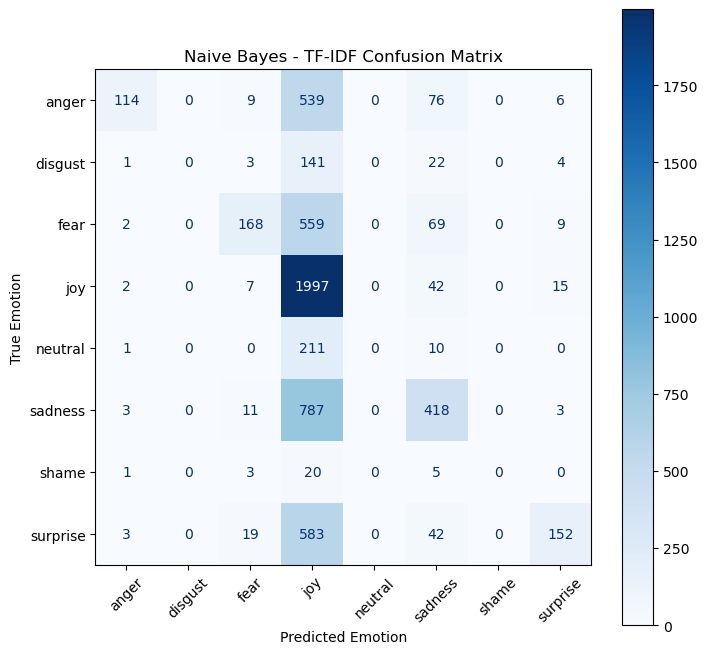

In [153]:
emo_labels = sorted(YN1_test.unique())
NBcm_tfidf = confusion_matrix(YN1_test, predictions_TFIDF, labels=emo_labels)
NBcm_display_tfidf = ConfusionMatrixDisplay(confusion_matrix=NBcm_tfidf, display_labels=emo_labels)

fig, ax = plt.subplots(figsize=(8, 8))
NBcm_display_tfidf.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Naive Bayes - TF-IDF Confusion Matrix")
plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")
plt.show()